# Simulação Computacional: Convolução como Filtragem (Média Móvel)

Neste experimento, aplicaremos a convolução para processar um sinal corrompido por ruído. O sistema utilizado será um filtro FIR de média móvel, cuja resposta ao impulso é um pulso retangular de amplitude $1/M$ e duração de $M$ amostras.

Analisaremos uma onda senoidal da rede elétrica ($60\,\text{Hz}$) contaminada por ruído gaussiano. O objetivo é avaliar o compromisso no design de filtros: o aumento da ordem $M$ melhora a rejeição ao ruído (suavização), mas introduz maior atraso temporal e atenuação na amplitude do sinal de interesse.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração de estilo acadêmico
sns.set_theme(
    context="paper", style="ticks", palette="colorblind", font="serif",
    rc={
        "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
        "axes.grid": True, "grid.linestyle": "--", "grid.alpha": 0.6,
        "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
        "mathtext.fontset": "cm",
    },
)
np.random.seed(42) # Para reprodutibilidade do ruído

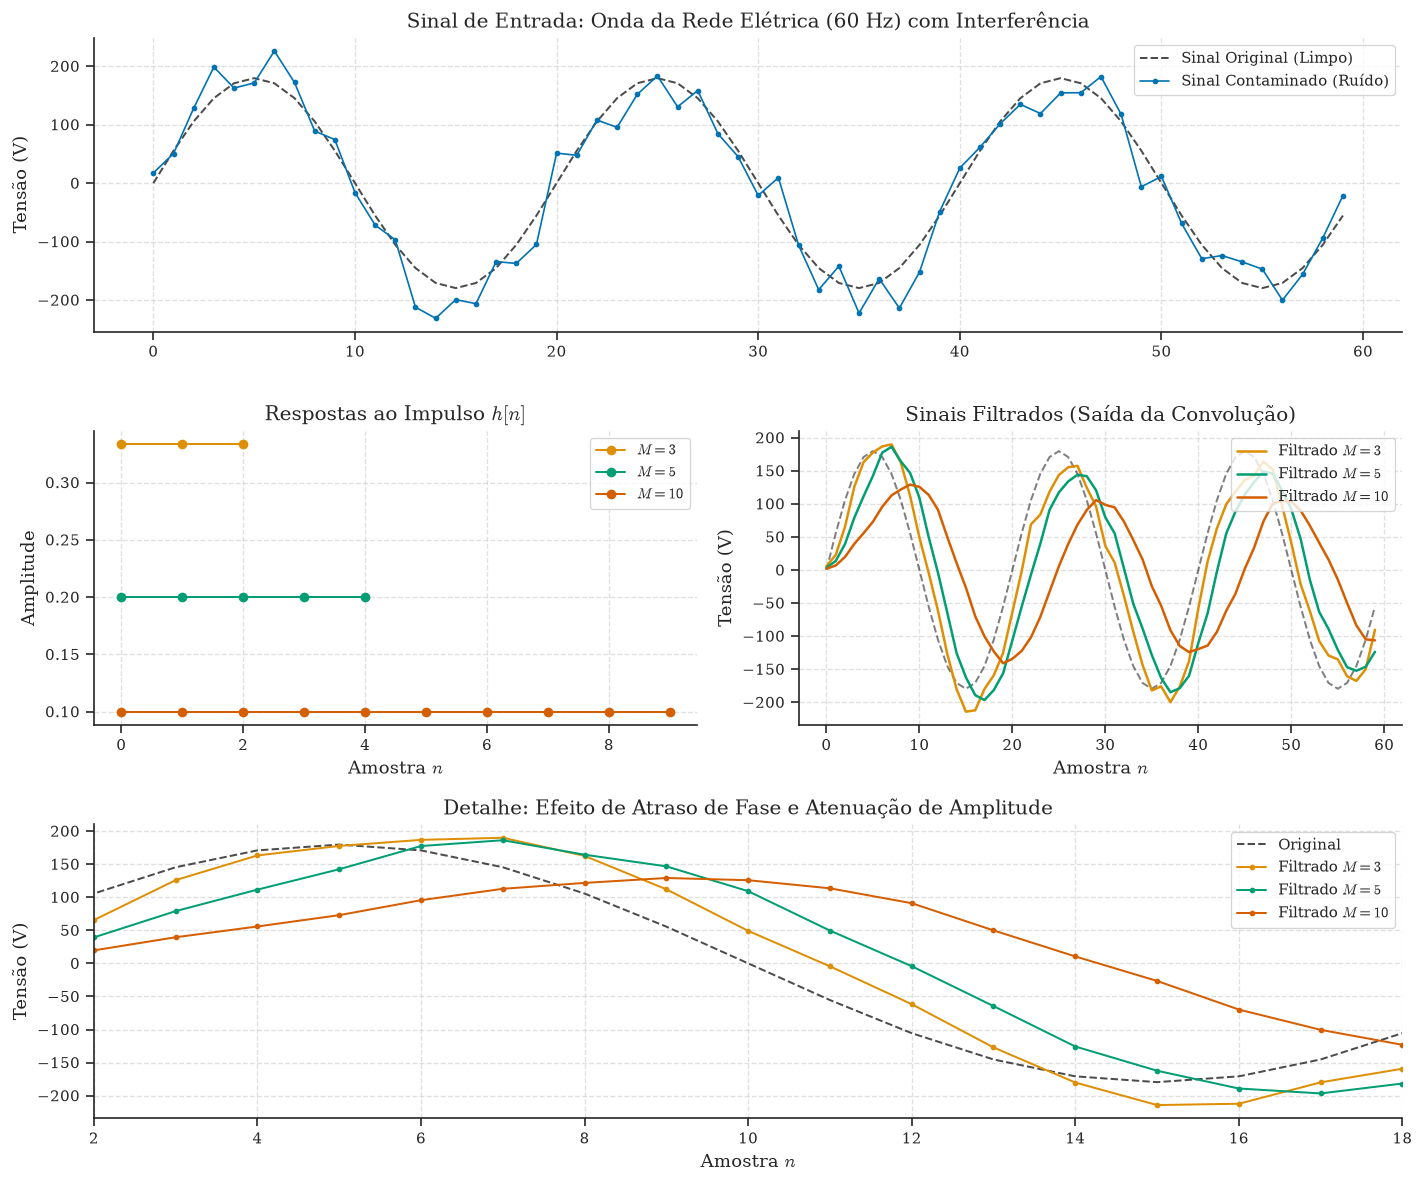

In [4]:
# 1. Geração do Sinal Original e Contaminado
f_rede = 60.0       # Frequência da rede elétrica (Hz)
f_s = 1200.0        # Frequência de amostragem (Hz) - 20 amostras por ciclo
N_amostras = 60     # 3 ciclos completos
n = np.arange(0, N_amostras)

# Sinal Limpo (179.6V de pico)
x_limpo = 179.6 * np.sin(2 * np.pi * (f_rede / f_s) * n)

# Adição de Ruído Branco Gaussiano
ruido = np.random.normal(0, 35.0, len(n)) # Desvio padrão de 35V
x_ruidoso = x_limpo + ruido

# 2. Definição das Respostas ao Impulso dos Filtros de Média Móvel
M_valores = [3, 5, 10]
h = {M: np.ones(M) / M for M in M_valores}

# 3. Filtragem via Convolução Discreta
y = {}
for M in M_valores:
    # A convolução causal ('full') gera atraso natural. 
    # Pegamos apenas as primeiras N_amostras para alinhar o eixo temporal com a entrada
    y[M] = np.convolve(x_ruidoso, h[M], mode='full')[:len(n)]

# 4. Configuração da Figura
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(3, 2)
cores = sns.color_palette("colorblind")

# Eixo 1: Sinais Originais e Ruidosos (ocupa toda a largura do topo)
ax0 = fig.add_subplot(gs[0, :])
ax0.plot(n, x_limpo, color='black', linestyle='--', alpha=0.7, label='Sinal Original (Limpo)')
ax0.plot(n, x_ruidoso, color=cores[0], marker='.', linestyle='-', linewidth=1, label='Sinal Contaminado (Ruído)')
ax0.set_title("Sinal de Entrada: Onda da Rede Elétrica (60 Hz) com Interferência")
ax0.set_ylabel("Tensão (V)")
ax0.legend(loc="upper right")

# Eixo 2: Respostas ao Impulso h[n]
ax1 = fig.add_subplot(gs[1, 0])
for i, M in enumerate(M_valores):
    ax1.plot(np.arange(M), h[M], marker='o', linestyle='-', color=cores[i+1], label=f'$M={M}$')
ax1.set_title(r"Respostas ao Impulso $h[n]$")
ax1.set_ylabel("Amplitude")
ax1.set_xlabel(r"Amostra $n$")
ax1.legend()

# Eixo 3: Comparação dos Sinais Filtrados
ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(n, x_limpo, color='black', linestyle='--', alpha=0.5)
for i, M in enumerate(M_valores):
    ax2.plot(n, y[M], color=cores[i+1], linewidth=1.5, label=f'Filtrado $M={M}$')
ax2.set_title("Sinais Filtrados (Saída da Convolução)")
ax2.set_ylabel("Tensão (V)")
ax2.set_xlabel(r"Amostra $n$")
ax2.legend(loc="upper right")

# Eixo 4: Foco no Atraso e Atenuação (Zoom nos picos)
ax3 = fig.add_subplot(gs[2, :])
ax3.plot(n, x_limpo, color='black', linestyle='--', alpha=0.7, label='Original')
for i, M in enumerate(M_valores):
    ax3.plot(n, y[M], color=cores[i+1], marker='.', linewidth=1.2, label=f'Filtrado $M={M}$')
ax3.set_xlim(2, 18) # Foco no primeiro ciclo positivo
ax3.set_title("Detalhe: Efeito de Atraso de Fase e Atenuação de Amplitude")
ax3.set_ylabel("Tensão (V)")
ax3.set_xlabel(r"Amostra $n$")
ax3.legend()

sns.despine(trim=False)
fig.tight_layout()

# Salvamento
os.makedirs(".", exist_ok=True)
fig.savefig("grafico_convolucao_filtragem.png")
plt.show()